# Modelo SARIMAX: Aplicación de variables exógenas y estacionalidad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast

# Modelo ARIMA con stasforecast
from statsforecast import StatsForecast
from statsforecast.models import ARIMA
from pmdarima.arima import nsdiffs

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 4)

## Problema a resolver

Utilizar el set de datos de demanda de electricidad que tiene un registro histórico de demnda en MW/h de una ciudad en el últio año. También se tienen los datos de temperatura horaria en el mismo periodo de tiempo. Esa va a ser la variable exógena a utilizar.

> Construir un modelo SARIMAX para pronosticar el nivel de demanda con un horizonte de 7 días en el futuro.

### Datos

In [2]:
df = pd.read_csv('datos/demanda_electricidad_sarimax.csv',
                parse_dates=['ds'])
df

,unique_id,ds,temperatura,y
0,demanda_electricidad,2025-01-01,15.7,131.2
1,demanda_electricidad,2025-01-02,15.0,135.1
2,demanda_electricidad,2025-01-03,16.3,129.1
3,demanda_electricidad,2025-01-04,17.8,117.4
4,demanda_electricidad,2025-01-05,15.3,120.7
...,...,...,...,...
360,demanda_electricidad,2025-12-27,14.9,124.9
361,demanda_electricidad,2025-12-28,16.6,119.8
362,demanda_electricidad,2025-12-29,14.3,136.9
363,demanda_electricidad,2025-12-30,15.3,136.0


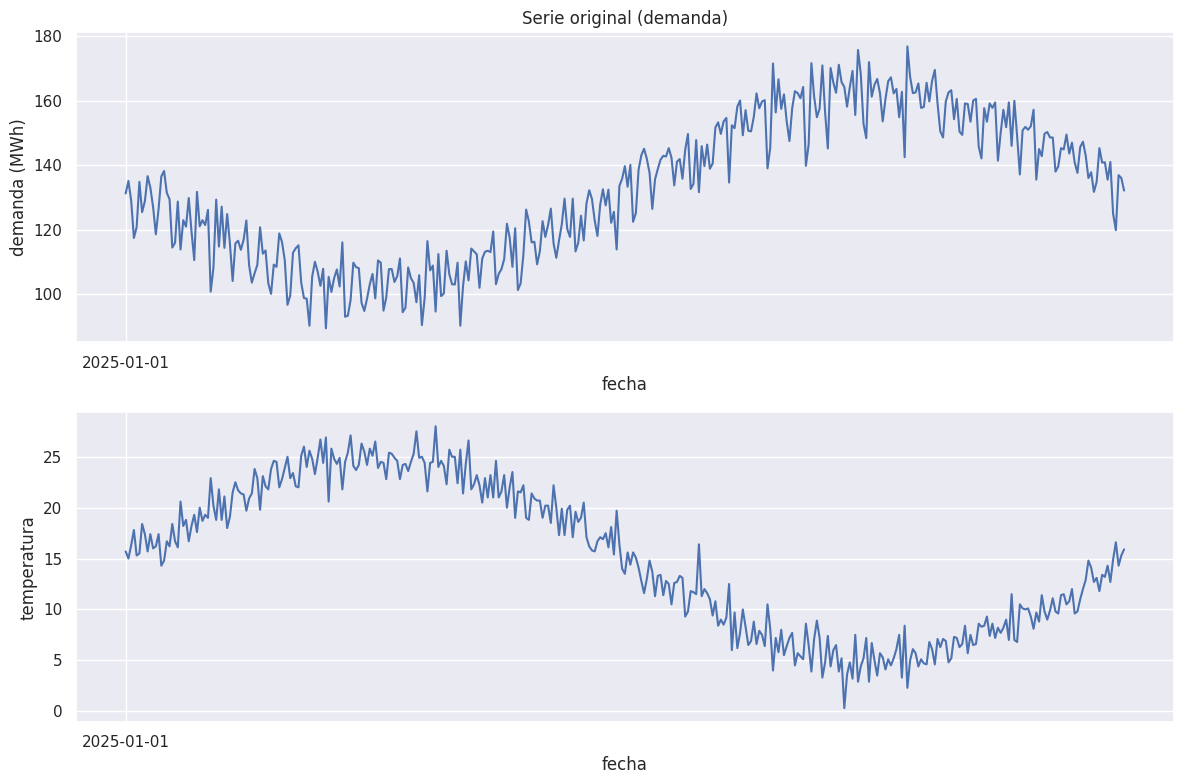

In [3]:
# Graficar serie y variables exógenas
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df, x="ds", y="y", ax=axs[0])
axs[0].set_title('Serie original (demanda)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('demanda (MWh)')
ticks = axs[0].get_xticks()
n = 60
axs[0].set_xticks(ticks[::n])

# Variable exógena (temperatura)
sns.lineplot(df, x="ds", y="temperatura", ax=axs[1])
axs[1].set_xlabel('fecha')
axs[1].set_xticks(ticks[::n])

plt.tight_layout();

## Estimación de los parámetros del modelo SARIMAX

1. Crear el set de entrenamiento y prueba
2. Ajustar un modelo de regresión **sobre las variables exógenas**
3. Calcular los residuales del modelo obtenido en (2)
4. Definir los parámetros del modelo SARIMA que se construirá **sobre los residuales obtenidos en (3)**
5. Habiendo definido los parámetros del modelo SARIMA (4), entrenar y validar el modelo SARIMAX
6. Generar pronósticos con el modelo obtenido en (5)

### 1. Set de entrenamiento y pruebas

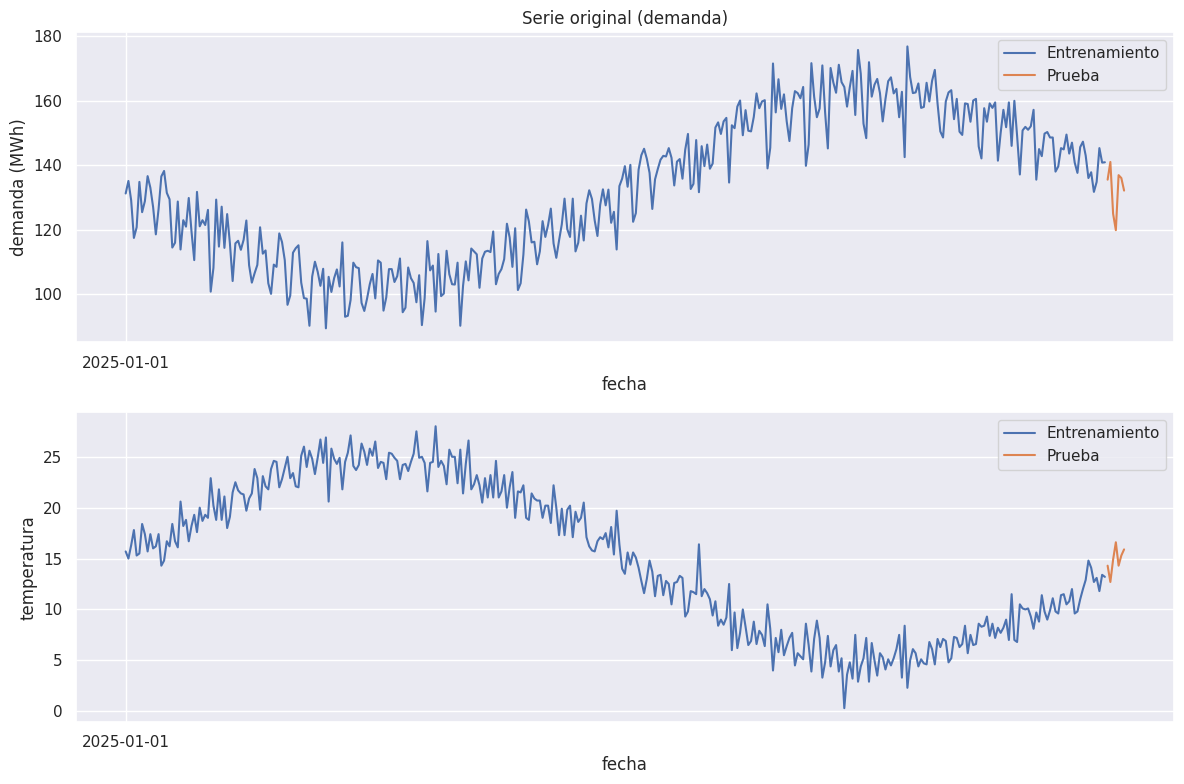

In [4]:
# Entrenamiento y prueba
df_train = df[:-7]
df_test = df[-7:] # Últimos 7 días de prueba

# Graficar
fig, axs = plt.subplots(2,1,figsize=(12,8))

# Serie
sns.lineplot(df_train, x="ds", y="y", ax=axs[0], label='Entrenamiento')
sns.lineplot(df_test, x="ds", y="y", ax=axs[0], label='Prueba')
axs[0].set_title('Serie original (demanda)')
axs[0].set_xlabel('fecha')
axs[0].set_ylabel('demanda (MWh)')
ticks = axs[0].get_xticks()
n = 60
axs[0].set_xticks(ticks[::n])

# Variables exógenas
sns.lineplot(df_train, x="ds", y="temperatura", ax=axs[1], label='Entrenamiento')
sns.lineplot(df_test, x="ds", y="temperatura", ax=axs[1], label='Prueba')
axs[1].set_xticks(ticks[::n])
axs[1].set_xlabel('fecha')
axs[1].legend()

plt.tight_layout();

### 2. Modelo de regresión para variables exógenas

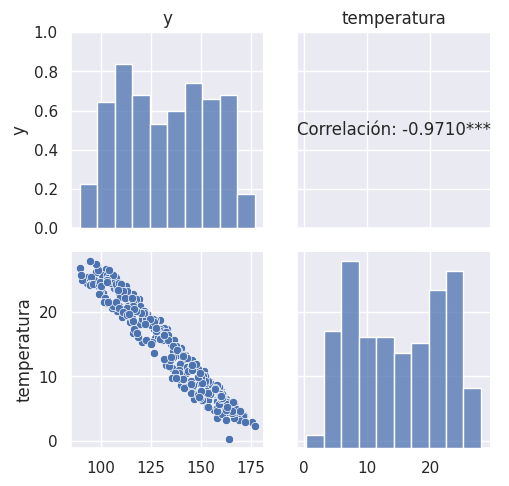

In [5]:
def correlacion(x, y, **kws):
    r, p = pearsonr(x, y)

    ax = plt.gca()
    ax.annotate(
        f"Correlación: {r:.4f}{'***' if p < 0.05 else ' '}",
        xy = (0.5, 0.5),
        xycoords = 'axes fraction',
        ha = 'center',
        va = 'center'
    )

df_plot = df_train[['y', 'temperatura']].copy()

pg = sns.PairGrid(df_plot)
pg.map_diag(sns.histplot)
pg.map_upper(correlacion)
pg.map_lower(sns.scatterplot)
pg.add_legend()

pg.set(xlabel='')
for i, col in enumerate(df_plot.columns):
    pg.axes[0,i].set_title(col)

una regresión lineal se ajusta perfecto en este caso

In [6]:
mlf = MLForecast(models = [LinearRegression()], freq='d')

mlf.fit(
    df = df_train,
    fitted = True, # para hacer la predicción in-sample y obtener los residuos
    static_features = [] # para indicar que se usa una exógena de valores contínuos
    )

pred_is = mlf.forecast_fitted_values() 
pred_is

,unique_id,ds,y,LinearRegression
0,demanda_electricidad,2025-01-01,131.2,130.233969
1,demanda_electricidad,2025-01-02,135.1,132.334368
2,demanda_electricidad,2025-01-03,129.1,128.433627
3,demanda_electricidad,2025-01-04,117.4,123.932773
4,demanda_electricidad,2025-01-05,120.7,131.434197
...,...,...,...,...
353,demanda_electricidad,2025-12-20,131.7,139.235677
354,demanda_electricidad,2025-12-21,134.8,138.035449
355,demanda_electricidad,2025-12-22,145.3,141.936189
356,demanda_electricidad,2025-12-23,140.8,137.135278


<Axes: xlabel='ds', ylabel='y'>

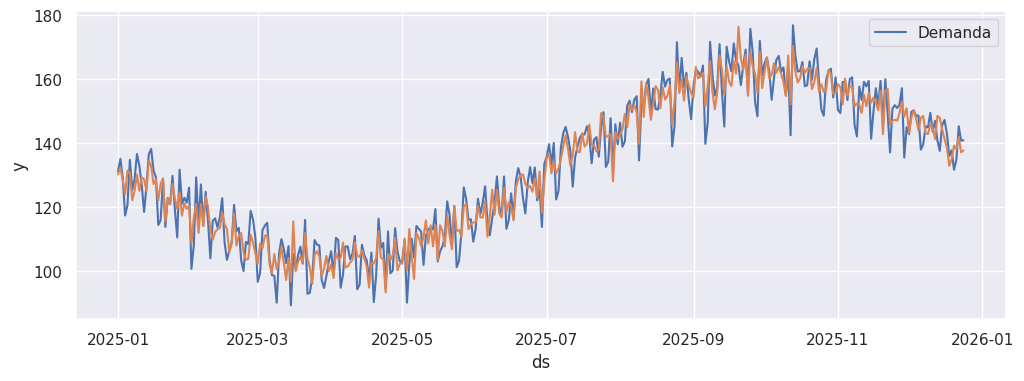

In [7]:
sns.lineplot(pred_is, x = 'ds', y = 'y', label = 'Demanda')
sns.lineplot(pred_is, x = 'ds', y = 'LinearRegression')

Este es el gráfico que captura las variaciónes abruptas de la serie de tiempo implementando una regresión lineal en la variable exógena.

A partir de este punto vamos a necesitar obtener los residuos y de ahi entrenar un modelo SARIMAX

### 3. Residuales del modelo de regresiónde las variables exógenas

<Axes: >

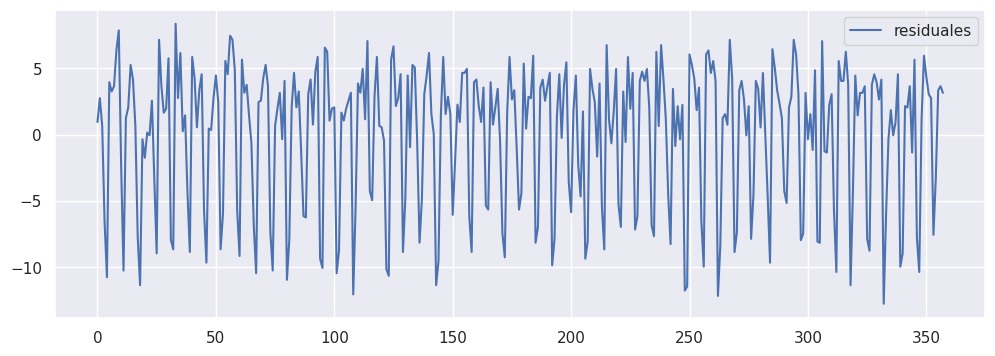

In [8]:
res = pred_is['y'] - pred_is['LinearRegression']
sns.lineplot(res, label = 'residuales')

Para poder conocer el valor de la periodicidad, usamos el ACF, porque ahí es sonde se puede observar el patrón estacional de los residuos.

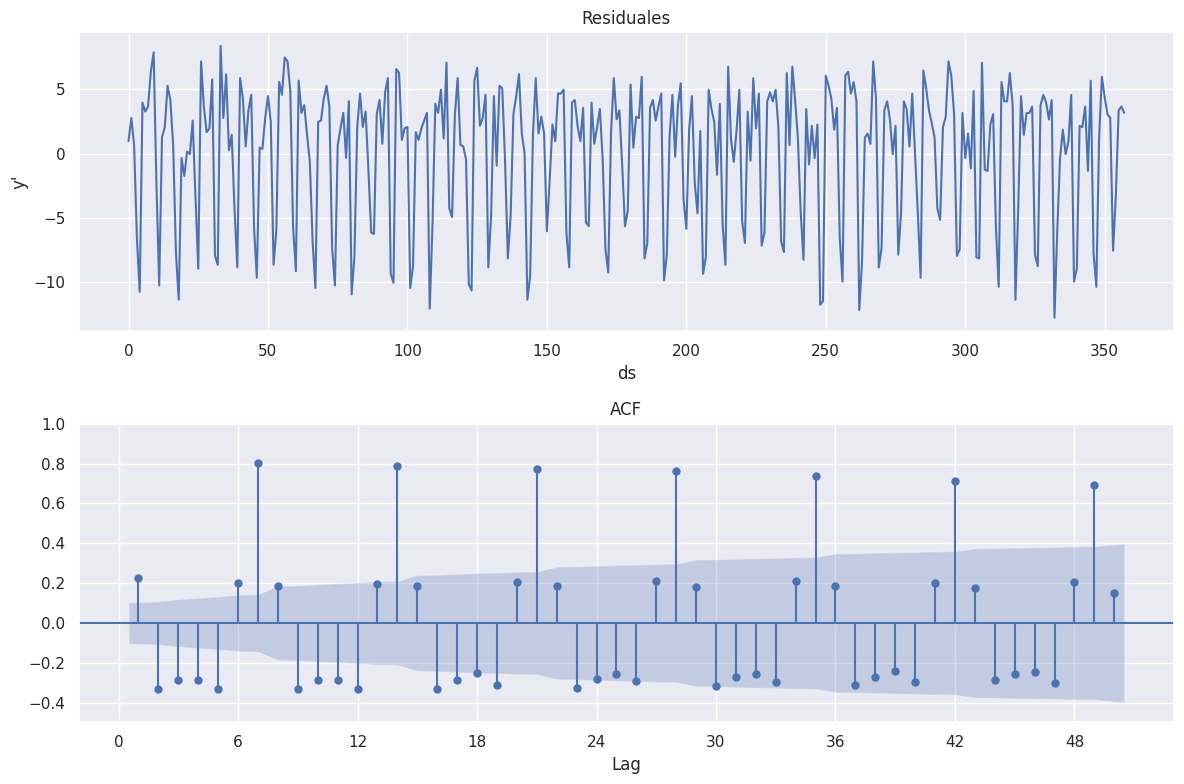

In [9]:
fig, axs = plt.subplots(2,1,figsize=(12,8))

sns.lineplot(res, ax=axs[0])
axs[0].set_xlabel('ds')
axs[0].set_ylabel("y'")
axs[0].set_title('Residuales')

LAGS = 50
plot_acf(res,
        alpha=0.05, 
        lags=LAGS,
        zero=False,
        auto_ylims=True,
        ax=axs[1])
axs[1].set_xlabel('Lag')
axs[1].set_xticks(range(0,LAGS+1))
axs[1].set_title('ACF')
axs[1].set_xticks(range(0, LAGS + 1, 6))
axs[1].grid(True)

plt.tight_layout()

Se puede observar que el patrón estacinal está marcado cada 7 días. Entonces ya se conoce el valor de **m**

### 4. Parámetros del modelo SARIMA construido a partir de los residuales

In [10]:
def prueba_diferenciacion(serie, d, D, m):
    serie = serie.dropna()

    if d != 0:
        for _ in range(d):
            serie = serie.diff()
    
    if D != 0:
        for _ in range(D):
            serie = serie.diff(m)
    
    resultado_estacionario = adfuller(serie.dropna())
    pvaladfuller = resultado_estacionario[1]

    print('>Prueba Estacionariedad con Dickey-Fuller')
    if pvaladfuller < 0.05:
        print('Rechazar H0: Serie Estacionaria')
        print(f'pval: {pvaladfuller:.4f} < 0.05')
        print('Ya no es necesario diferenciar más')
    else:
        print('Aceptar H0: Serie No Estacionaria')
        print(f'pval: {pvaladfuller:.4f} > 0.05')
        print('Diferenciar nuevamente')

    D_necesaria = nsdiffs(serie.dropna(), m=m, test='ch') 

    print('\n>Prueba Estacionalidad con Canova‑Hansen')
    if D_necesaria > 0:
        print("La serie presenta un patrón estacional")
    else:
        print("Puede no haber un patrón estacional")

    fig, ax = plt.subplots(1, 1, figsize = (15, 5))
    plt.plot(range(1, len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin = 1, xmax = len(serie)+1, color = 'red', label = 'Media', linestyle = '--')
    plt.title(f'Serie d = {d}, D = {D}, m = {m}')
    plt.xlabel('Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.show()

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


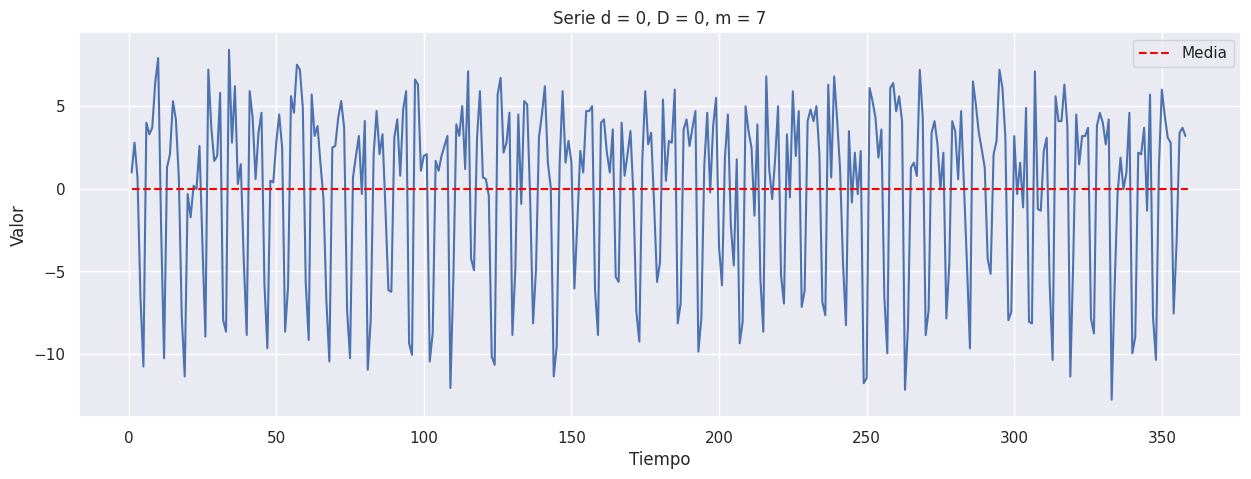

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


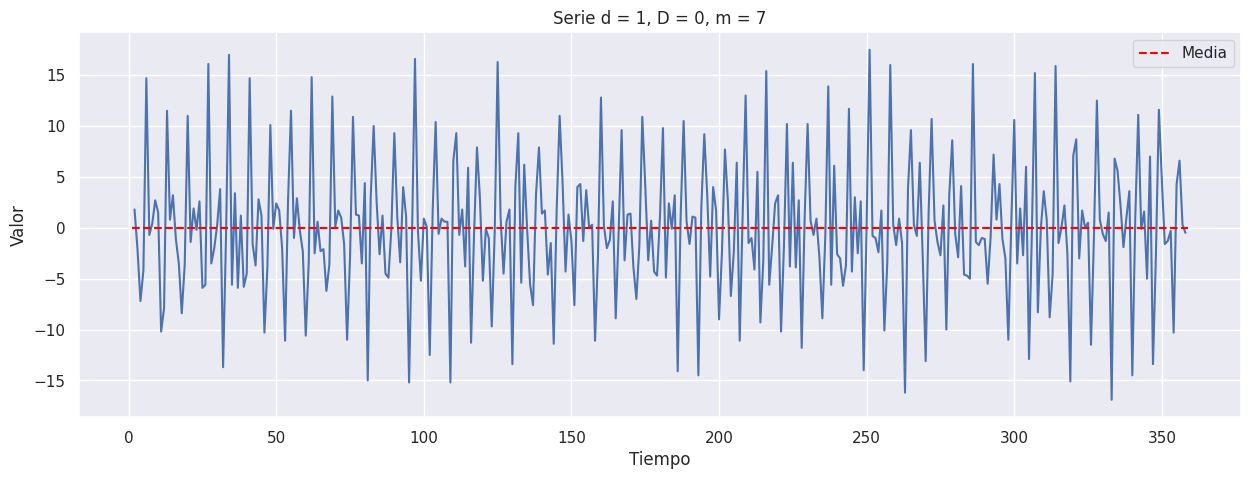

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


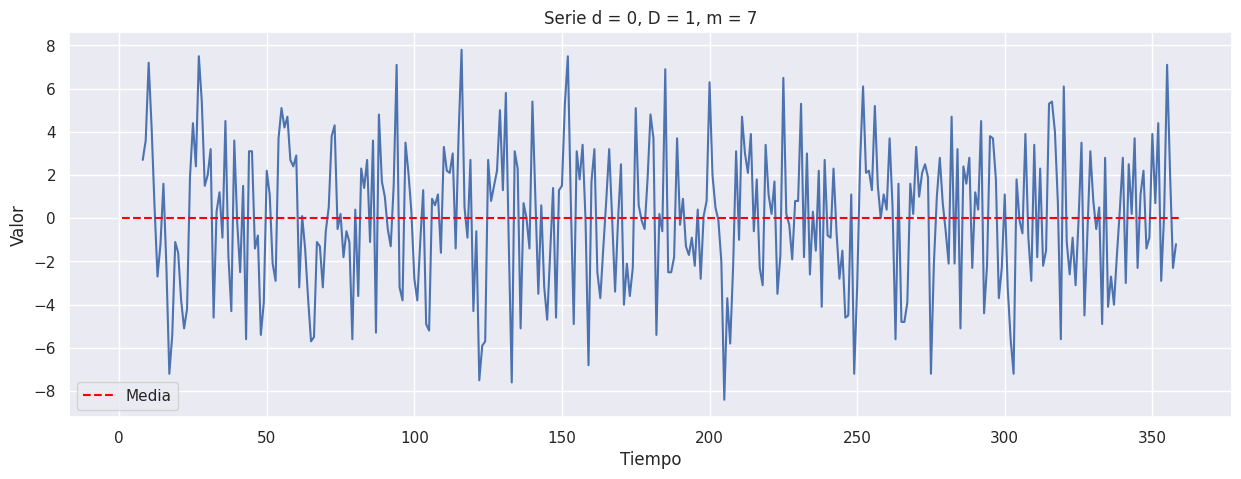

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


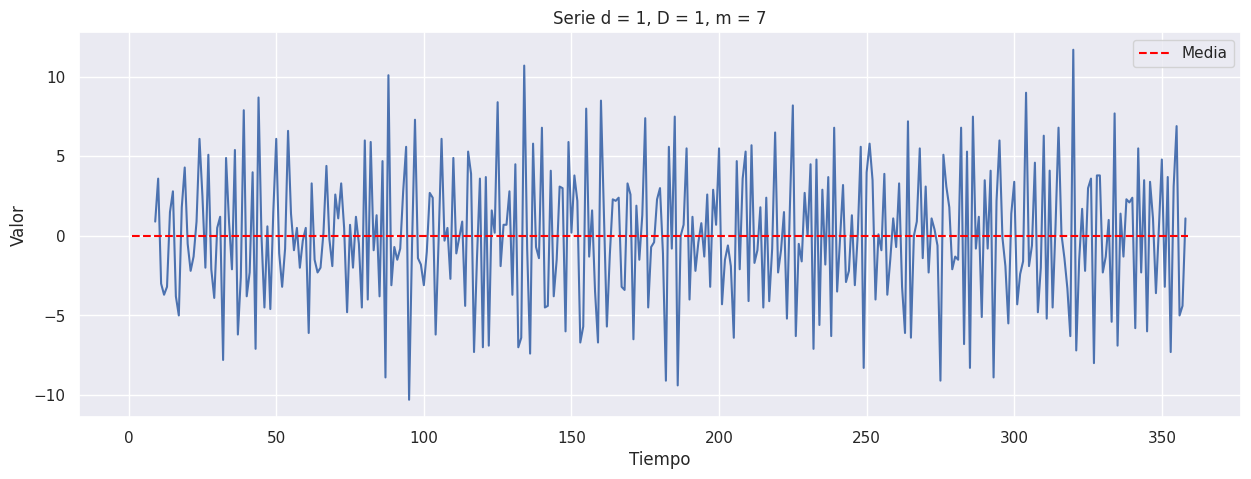

In [11]:
prueba_diferenciacion(res, d=0, D=0, m=7)
prueba_diferenciacion(res, d=1, D=0, m=7)
prueba_diferenciacion(res, d=0, D=1, m=7)
prueba_diferenciacion(res, d=1, D=1, m=7)

Se puede escojer:
* d = 0 y D = 1
* d = 1 y D = 1 * usar esta opción

Verificación con los gráficos PACF y ACF

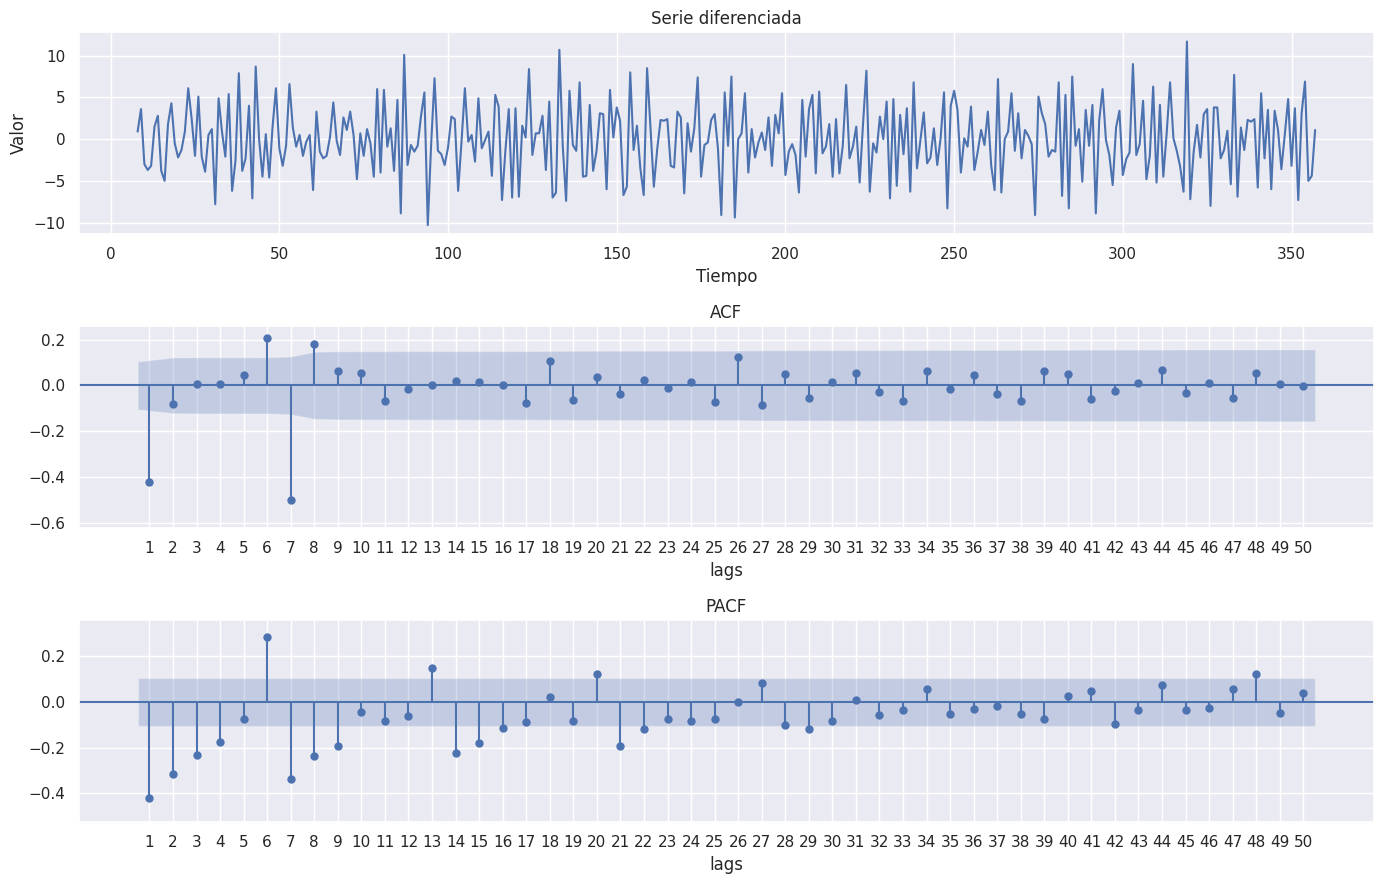

In [12]:
# Diferenciación d = 1, D = 1
m = 7
res_diff = res.copy()
res_diff = res_diff.diff()
res_diff = res_diff.diff(m).dropna()

fig, ax = plt.subplots(3,1, figsize = (14, 9))

sns.lineplot(res_diff, ax = ax[0])
ax[0].set_title('Serie diferenciada')
ax[0].set_xlabel('Tiempo')
ax[0].set_ylabel('Valor')

LAGS = 50
plot_acf(res_diff,
        alpha = 0.05,
        lags = LAGS,
        zero = False,
        auto_ylims = True,
        ax = ax[1])
ax[1].set_title('ACF')
ax[1].set_xlabel('lags')
ax[1].set_xticks(range(1, LAGS+1))
ax[1].grid(True)

plot_pacf(res_diff,
        alpha = 0.05,
        lags = LAGS,
        zero = False,
        auto_ylims = True,
        ax = ax[2])
ax[2].set_title('PACF')
ax[2].set_xlabel('lags')
ax[2].set_xticks(range(1, LAGS+1))
ax[2].grid(True)

plt.tight_layout()

- **Q** : Es claro que el múltiplo tiene un valor de 1
- **q** : También se tiene un valor de 1
- **P** : No se tiene una caía abrupta en los múltiplos, asi que maximo es 1
- **p** : Tampoco se tiene una caía abrupta, se deha en 1

# AQUÍ ESTÁ LA DIFERENCIA !!!!

hay que hacer una búsqueda de diferentes valores para poder validar cual es el mejor de todos

In [19]:
ps, d, q = [1, 2, 3], 1, 1
Ps, D, Q = [0, 1], 1, 1

modelos = [ARIMA(order=(p, d, q), alias=f'ARIMAX({p},{d},{q})({P},{D},{Q})', include_constant= (d == 0)) for p in ps for P in Ps] 

sf = StatsForecast(
    models=modelos,
    freq='d',
    n_jobs=-1
)

print(f'Se generaron: {len(modelos)} modelos diferentes')
print(sf)

Se generaron: 6 modelos diferentes
StatsForecast(models=[ARIMAX(1,1,1)(0,1,1),ARIMAX(1,1,1)(1,1,1),ARIMAX(2,1,1)(0,1,1),ARIMAX(2,1,1)(1,1,1),ARIMAX(3,1,1)(0,1,1),ARIMAX(3,1,1)(1,1,1)])


### Validación cruzada

In [20]:
cv_df = sf.cross_validation(
    df=df_train,        
    h=24,
    step_size=24,
    n_windows=10
)

In [21]:
cv_df

,unique_id,ds,cutoff,y,"ARIMAX(1,1,1)(0,1,1)","ARIMAX(1,1,1)(1,1,1)","ARIMAX(2,1,1)(0,1,1)","ARIMAX(2,1,1)(1,1,1)","ARIMAX(3,1,1)(0,1,1)","ARIMAX(3,1,1)(1,1,1)"
0,demanda_electricidad,2025-04-29,2025-04-28,106.1,99.292270,99.292270,103.314748,103.314748,103.314468,103.314468
1,demanda_electricidad,2025-04-30,2025-04-28,103.0,101.537709,101.537709,103.101738,103.101738,103.163677,103.163677
2,demanda_electricidad,2025-05-01,2025-04-28,102.9,101.425755,101.425755,101.528659,101.528659,101.240670,101.240670
3,demanda_electricidad,2025-05-02,2025-04-28,109.7,111.165772,111.165772,110.248833,110.248833,110.145100,110.145100
4,demanda_electricidad,2025-05-03,2025-04-28,90.1,98.752755,98.752755,100.242737,100.242737,100.261618,100.261618
...,...,...,...,...,...,...,...,...,...,...
235,demanda_electricidad,2025-12-20,2025-11-30,131.7,138.707559,138.707559,138.926079,138.926079,138.999736,138.999736
236,demanda_electricidad,2025-12-21,2025-11-30,134.8,137.470066,137.470066,137.703831,137.703831,137.790944,137.790944
237,demanda_electricidad,2025-12-22,2025-11-30,145.3,141.491918,141.491918,141.679085,141.679085,141.746828,141.746828
238,demanda_electricidad,2025-12-23,2025-11-30,140.8,136.541947,136.541947,136.785424,136.785424,136.884622,136.884622


In [22]:
def metricas_cv(cv_df, nombre_modelos):
    resultados = []
    for modelo in nombre_modelos:
        #Agrupar por cutoff y calcular métricas
        metricas_ventana = []
        for cutoff in cv_df['cutoff'].unique():
            ventana = cv_df[cv_df['cutoff'] == cutoff]
            y_true = ventana['y'].values
            y_pred = ventana[modelo].values
            errores = y_true - y_pred

            rmse = np.sqrt(np.mean(errores**2))         
            mape = np.mean(np.abs(errores / y_true)) * 100
            mae = np.mean(np.abs(errores))
            mae = np.mean(np.abs(errores))

            metricas_ventana.append({'rmse' : rmse, 'mape' : mape, 'mae' : mae})
        
        metricas_df = pd.DataFrame(metricas_ventana)
        resultados.append({
            'Modelo'   : modelo,
            'RMSE'     : metricas_df['rmse'].mean(),
            'MAPE'     : metricas_df['mape'].mean(),
            'MAE'      : metricas_df['mae'].mean(),
            'RMSE_STD' : metricas_df['rmse'].std(),
            'MAPE_STD' : metricas_df['mape'].std(),     
            'MAE_STD'  : metricas_df['mae'].std()    
        })
    df_resultados = pd.DataFrame(resultados)
    df_resultados.index = df_resultados.index + 1
    return df_resultados

In [23]:
alias_modelos = [m.alias for m in modelos]
metricas_sarimas = metricas_cv(cv_df, alias_modelos)
metricas_sarimas

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
1,"ARIMAX(1,1,1)(0,1,1)",5.407368,3.183981,4.370342,0.488300,0.548466,0.508805
2,"ARIMAX(1,1,1)(1,1,1)",5.407368,3.183981,4.370342,0.488300,0.548466,0.508805
3,"ARIMAX(2,1,1)(0,1,1)",5.259011,3.188729,4.410726,0.468224,0.437503,0.462297
4,"ARIMAX(2,1,1)(1,1,1)",5.259011,3.188729,4.410726,0.468224,0.437503,0.462297
5,"ARIMAX(3,1,1)(0,1,1)",5.298524,3.218806,4.452760,0.452267,0.435382,0.460113
6,"ARIMAX(3,1,1)(1,1,1)",5.298524,3.218806,4.452760,0.452267,0.435382,0.460113


se encuentra que el modelo entrenado previamente tiene medidas de desempeño iguales a las del modelo encontrado

### 5. Entrenar un modelo SARIMAX

Aqui se utiliza el conjunto de entrenamiento, no los residuales. Así que al entrenar los datos de entrenamiento pero tomando en cuenta los parámetros ARIMAX encontrados, es como automáticamente se convierte en un SARIMAX.

In [24]:
models = [ARIMA(order = (1, 1, 1),
                seasonal_order= (0, 1, 1),
                season_length = m,
                alias = 'SARIMAX(1, 1, 1)(0, 1, 1)_7')]
sf = StatsForecast(models = models, freq = 'd')
sf

StatsForecast(models=[SARIMAX(1, 1, 1)(0, 1, 1)_7])

Este es el momento en el que se transforma en un SARIMAX

In [25]:
sf.fit(df = df_train)

StatsForecast(models=[SARIMAX(1, 1, 1)(0, 1, 1)_7])

In [26]:
mod_arimax = sf.fitted_[0][0]
mod_arimax_params = mod_arimax.model_
print(f"Parámetros del modelo: {mod_arimax_params.get('coef')}")

Parámetros del modelo: {'ar1': np.float64(0.01435463013178907), 'ma1': np.float64(-0.7511433303670513), 'sma1': np.float64(-0.8560398634274936), 'ex_1': np.float64(-3.0326222084307775)}


### 6. Generar pronósticos con el modelo SARIMAX entrenado

In [27]:
df_test

,unique_id,ds,temperatura,y
358,demanda_electricidad,2025-12-25,14.3,135.5
359,demanda_electricidad,2025-12-26,12.7,141.0
360,demanda_electricidad,2025-12-27,14.9,124.9
361,demanda_electricidad,2025-12-28,16.6,119.8
362,demanda_electricidad,2025-12-29,14.3,136.9
363,demanda_electricidad,2025-12-30,15.3,136.0
364,demanda_electricidad,2025-12-31,15.9,132.1


In [28]:
exogenas = df_test.drop(columns = ['y'])

In [29]:
fc = sf.forecast(df = df_train, X_df = exogenas, h = 7, level = [90])
fc

,unique_id,ds,"SARIMAX(1, 1, 1)(0, 1, 1)_7","SARIMAX(1, 1, 1)(0, 1, 1)_7-lo-90","SARIMAX(1, 1, 1)(0, 1, 1)_7-hi-90"
0,demanda_electricidad,2025-12-25,137.551372,133.410662,141.692081
1,demanda_electricidad,2025-12-26,143.724768,139.443026,148.006510
2,demanda_electricidad,2025-12-27,125.021764,120.614087,129.429440
3,demanda_electricidad,2025-12-28,120.950498,116.420531,125.480465
4,demanda_electricidad,2025-12-29,138.446486,133.797447,143.095525
5,demanda_electricidad,2025-12-30,135.293285,130.528148,140.058422
6,demanda_electricidad,2025-12-31,133.339223,128.460750,138.217696


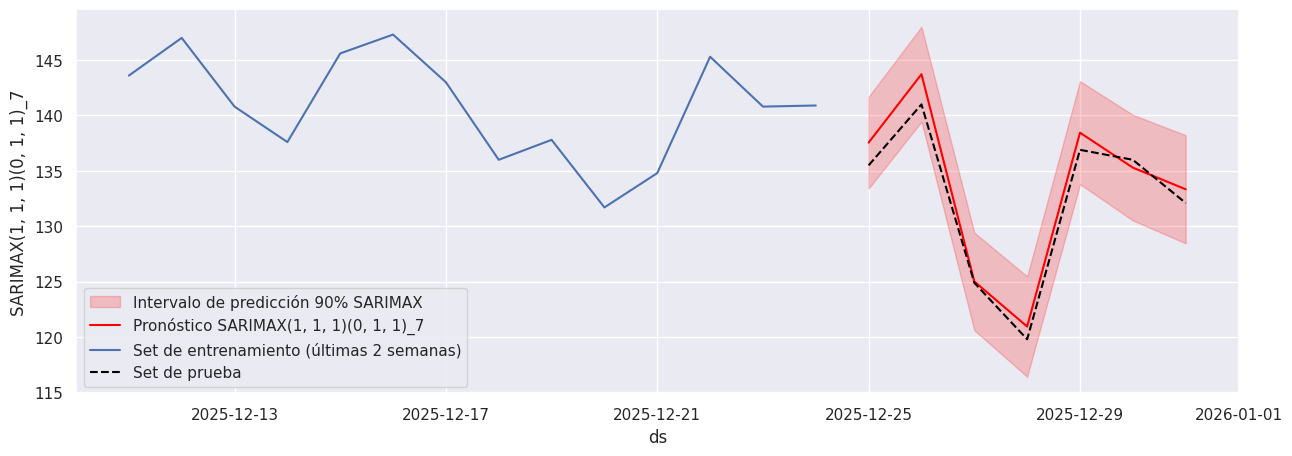

In [30]:
# Graficar
fig, ax = plt.subplots(figsize = (15, 5))

# ARIMAX: pronóstico puntual e intervalo de predicción
plt.fill_between(x=fc["ds"],
                y1 = fc['SARIMAX(1, 1, 1)(0, 1, 1)_7-lo-90'],
                y2 = fc['SARIMAX(1, 1, 1)(0, 1, 1)_7-hi-90'],
                color = 'red',
                alpha = 0.2,
                label = 'Intervalo de predicción 90% SARIMAX');
sns.lineplot(fc, x="ds", y="SARIMAX(1, 1, 1)(0, 1, 1)_7", color='red', label='Pronóstico SARIMAX(1, 1, 1)(0, 1, 1)_7')

sns.lineplot(df_train[-14:], x="ds", y="y", label='Set de entrenamiento (últimas 2 semanas)')
sns.lineplot(df_test, x="ds", y="y", label='Set de prueba', color='black', linestyle='--');

### 7. Ahora una predicción de lo que va a pasar mas allá de los datos de pruebas.

Necesitamos generar un dataset con las variables exógenas que supuestamente nosotros podríamos conocer a futuro.

In [31]:
models = [ARIMA(order=(1, 1, 1), 
                seasonal_order = (0, 1, 1),
                season_length = 7,
                alias='SARIMAX(1, 1, 1)(0, 1, 1)_7')]
sf = StatsForecast(models=models, freq='d')

h = 7
fechas_futuras = pd.date_range(start = df['ds'].max() + pd.Timedelta(days = 1), periods = h, freq = 'd')
exogenas_futuro = pd.DataFrame({
    'unique_id' : df['unique_id'].iloc[0],
    'ds' : fechas_futuras,
    'temperatura' : [13, 12, 11, 14, 15, 10, 11]
})

fc = sf.forecast(df = df, X_df = exogenas_futuro, h = 7, level = [90])
fc

,unique_id,ds,"SARIMAX(1, 1, 1)(0, 1, 1)_7","SARIMAX(1, 1, 1)(0, 1, 1)_7-lo-90","SARIMAX(1, 1, 1)(0, 1, 1)_7-hi-90"
0,demanda_electricidad,2026-01-01,140.551898,136.440068,144.663729
1,demanda_electricidad,2026-01-02,144.808274,140.556028,149.060519
2,demanda_electricidad,2026-01-03,136.182861,131.806328,140.559395
3,demanda_electricidad,2026-01-04,128.025030,123.527817,132.522242
4,demanda_electricidad,2026-01-05,135.458174,130.843440,140.072907
5,demanda_electricidad,2026-01-06,150.816437,146.087102,155.545772
6,demanda_electricidad,2026-01-07,147.370816,142.529592,152.212041


<Axes: xlabel='ds', ylabel='SARIMAX(1, 1, 1)(0, 1, 1)_7'>

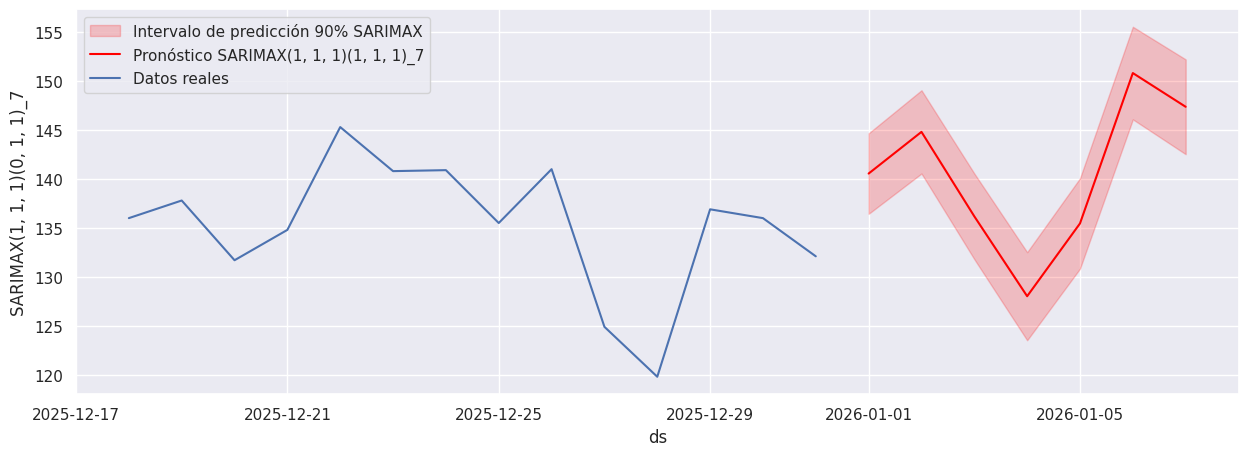

In [33]:

fig, ax = plt.subplots(figsize = (15, 5))

plt.fill_between(x=fc["ds"],
                y1 = fc['SARIMAX(1, 1, 1)(0, 1, 1)_7-lo-90'],
                y2 = fc['SARIMAX(1, 1, 1)(0, 1, 1)_7-hi-90'],
                color = 'red',
                alpha = 0.2,
                label = 'Intervalo de predicción 90% SARIMAX');
sns.lineplot(fc, x="ds", y="SARIMAX(1, 1, 1)(0, 1, 1)_7", color='red', label='Pronóstico SARIMAX(1, 1, 1)(1, 1, 1)_7')

sns.lineplot(df[-14:], x="ds", y="y", label='Datos reales')